In [63]:
import pandas as pd
from collections import Counter
import numpy as np
from scipy.stats import entropy

In [64]:
def jsd_divergence_between_sets(set1, set2, base=2):

    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results

In [ ]:
# group_var_dict = {"V201549x" : "Race", 'V202022' : "Discuss Politics", 'V201200' : "Ideology", 'V201231x' : "Party", 
#                   'V201452' : "Church", 'V201600' : "Gender", 'V202406' : "Political Interest"}

# groups = {
#     'V201549x': {1: 'White', 2: 'Black', 3: 'Asian', 4: 'Native American', 5: 'Hispanic'},
#     'V202022': {
#             # 1: 'Like to discuss politics with my family and friends.',
#             # 2: 'Never discuss politics with my family or friends.'
#             1: 'Like to discuss politics',
#             2: 'Never discuss politics'
#             },
#     'V201200': {
#             1: "Liberal",
#             2: "Liberal",
#             3: "Liberal",
#             4: "Moderate",
#             5: "Conservative",
#             6: "Conservative",
#             7: "Conservative"
#         },
#     'V201231x': {
#             1: "Democrat",
#             2: "Democrat",
#             3: "Independent",
#             4: "Independent",
#             5: "Independent",
#             6: "Republican",
#             7: "Republican"
#         },
#     'V201452': {1: "Attend church", 2: "Does not attend church"},
#     'V201600': {1: "Man", 2: "Woman"},
# }

In [65]:
group_var_dict = {"V201549x" : "Race", 'V202022' : "Discuss Politics", 'V201200' : "Ideology", 'V201231x' : "Party", 
                  'V201452' : "Church", 'V201600' : "Gender", 'V202406' : "Political Interest"}

groups = {
    'V201549x': {1: 'White', 2: 'Black', 3: 'Asian', 4: 'Native American', 5: 'Hispanic'},
    'V202022': {
            1: 'Like to discuss politics',
            2: 'Never discuss politics'
            },
    'V201200': {
            1: "Extremely liberal",
            2: "Liberal",
            3: "Slightly liberal",
            4: "Moderate",
            5: "Slightly conservative",
            6: "Conservative",
            7: "Extremely conservative"
        },
    'V201231x': {
            1: "Strong democrat",
            2: "Weak democrat",
            3: "Democrat-leaning indep.",
            4: "Independent",
            5: "Republican-leaning indep.",
            6: "Weak republican",
            7: "Strong republican"
        },
    'V201452': {1: "Attend church", 2: "Does not attend church"},
    'V201600': {1: "Man", 2: "Woman"},
    'V202406': {1: "Very", 2: "Somewhat", 3: "Not very", 4: "Not at all"}
}


label_to_group = {}

for var, mapping in groups.items():
    for code, label in mapping.items():
        label_to_group[label] = group_var_dict[var]

In [76]:
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}
qids_reverse_coded = ["V201416", "V202234", "V202257", "V202287", "V202332", "V202371"]

groups_keys = groups.keys()

def get_counts_group(path, qids, key): #function to get a dict with counts for each question

    value_list = {}

    for number, group in groups[key].items():

        value_list[group] = []

        for id in qids:
            df = pd.read_csv(path + id + ".csv")
            df_group = df[df[key] == number]

            df_group.loc[:, 'Response'] = pd.to_numeric(df_group['Response'], errors='coerce')     
            value_counts = Counter(df_group['Response'].dropna())

            if id in ["V201324", "V202332"]:

                answers = {i: value_counts[i] for i in range(1, 6)}
            else:
                answers = {i: value_counts[i] for i in range(1, 4)}

            value_list[group].append({name_dict[id] : answers})

    return value_list

In [67]:
def get_human_counts_group(path, qids, key): #getting results from anes 2020
     
    value_list = {}

    for number, group in groups[key].items():

        value_list[group] = []

        df = pd.read_csv(path)

        df_group = df[df[key] == number]

        for id in qids:

            human_counts = Counter(df_group[id].dropna())

            if id in ["V201324", "V202332"]:

                answers = {i: human_counts[i] for i in range(1, 6)}
            else:
                answers = {i: human_counts[i] for i in range(1, 4)}

            value_list[group].append({name_dict[id] : answers})

    return value_list

#human_results = get_human_counts_group("data/2020 ANES_test.csv", qids)

In [91]:
qids,qids_reverse_coded

(['V201324',
  'V201416',
  'V202234',
  'V202257',
  'V202287',
  'V202332',
  'V202337',
  'V202348',
  'V202371',
  'V202378'],
 ['V201416', 'V202234', 'V202257', 'V202287', 'V202332', 'V202371'])

In [92]:
# GPT-4.1
model_name = 'gpt4.1'
human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}
priming_results_groups = {}
preamble_results_groups = {}
reversed_results_groups = {}

for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_reform_results/full_results_2020_", qids, key)
    priming_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_priming_results/full_results_2020_", qids, key)
    preamble_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_preamble_results/full_results_2020_", qids, key)
    reversed_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded, key)

results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]    



/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pa

In [ ]:
# Llama8b
model_name = 'llama8b'
human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}
priming_results_groups = {}
preamble_results_groups = {}
reversed_results_groups = {}

for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("MLLM Results/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("MLLM Results/main_mq_reform_3rdP_results/full_results_2020_", qids, key)
    priming_results_groups[group_var_dict[key]] = get_counts_group("MLLM Results/Priming/Original/full_results_2020_", qids, key)
    preamble_results_groups[group_var_dict[key]] = get_counts_group("MLLM Results/Preamble/Original/full_results_2020_", qids, key)
    reversed_results_groups[group_var_dict[key]] = get_counts_group("MLLM Results/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded, key)

results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]    

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_33838/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_33838/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_33838/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_33838/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pa

In [ ]:
# llama70b
model_name = 'llama70b'
human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}
priming_results_groups = {}
preamble_results_groups = {}
reversed_results_groups = {}
for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_reform_results/full_results_2020_", qids, key)
    priming_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_priming_results/full_results_2020_", qids, key)
    preamble_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_preamble_results/full_results_2020_", qids, key)
    reversed_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/70B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded, key)

results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]    




/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_47016/3705012249.py:9: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pa

In [78]:
replicate_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            replicate_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[1][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in replicate_jsd_groups}

replicate_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
replicate_jsd_groups_df.head(20)

replicate_jsd_groups_df['Average'] = replicate_jsd_groups_df.mean(axis=1)
# replicate_jsd_groups_df = replicate_jsd_groups_df.sort_values('Average', ascending=False) # do not sort


# add one higher-level index (Group) above the existing row labels
replicate_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [replicate_jsd_groups_df.index.map(label_to_group), replicate_jsd_groups_df.index],
    names=["Group", "Category"]
)


In [70]:
replicate_jsd_groups_df.head(10)

Current Economy  Gay Marriage  \
Group            Category                                                  
Race             White                            0.124966      0.029321   
                 Black                            0.144394      0.070266   
                 Asian                            0.107062      0.049657   
                 Native American                  0.062256      0.050333   
                 Hispanic                         0.105883      0.086134   
Discuss Politics Like to discuss politics         0.123297      0.032829   
                 Never discuss politics           0.106852      0.051103   
Ideology         Extremely liberal                0.292056      0.031806   
                 Liberal                          0.158830      0.033695   
                 Slightly liberal                 0.131426      0.064903   

                                           Refugee Allowing  \
Group            Category                                     
Race             White                             0.178377   
                 Black                             0.204810   
                 Asian                             0.187840   
                 Native American                   0.198237   
                 Hispanic                          0.234612   
Discuss Politics Like to discuss politics          0.172878   
                 Never discuss politics            0.292871   
Ideology         Extremely liberal                 0.058766   
                 Liberal                           0.069950   
                 Slightly liberal                  0.115086   

                                           Income Inequality  Gender Role  \
Group            Category                                                   
Race             White                              0.136141     0.004077   
                 Black                              0.145261     0.000161   
                 Asian                              0.169217     0.002050   
                 Native American                    0.192591     0.005783   
                 Hispanic                           0.176170     0.002758   
Discuss Politics Like to discuss politics           0.129683     0.002941   
                 Never discuss politics             0.278245     0.008284   
Ideology         Extremely liberal                  0.076514     0.341022   
                 Liberal                            0.087540     0.050560   
                 Slightly liberal                   0.134152     0.027627   

                                           Climate Change  Gun Regulation  \
Group            Category                                                   
Race             White                           0.101455        0.244167   
                 Black                           0.159486        0.197280   
                 Asian                           0.125435        0.223704   
                 Native American                 0.157828        0.266767   
                 Hispanic                        0.160541        0.299423   
Discuss Politics Like to discuss politics        0.111319        0.236832   
                 Never discuss politics          0.103815        0.199083   
Ideology         Extremely liberal               0.063399        0.090680   
                 Liberal                         0.094145        0.073407   
                 Slightly liberal                0.272633        0.141836   

                                           Drug Addiction  Race Diversity  \
Group            Category                                                   
Race             White                           0.173905        0.209564   
                 Black                           0.159677        0.246242   
                 Asian                           0.153104        0.238020   
                 Native American                 0.154179        0.187747   
                 Hispanic                        0.181850    

In [121]:
# results = [human_results_groups, replicate_results_groups, reformulated_results_groups, priming_results_groups, preamble_results_groups, reversed_results_groups]  
reversed_results_groups['Race']['White'][5]

{'Race Diversity': {1: 40, 2: 3332, 3: 559}}

In [124]:
reversed_results_groups['Race']['White'][5]

{'Race Diversity': {1: 3332, 2: 40, 3: 559}}

In [ ]:
from copy import deepcopy 
# reversed_results_groups = {list(d.keys())[0]: list(d.values())[0] for d in reversed_results_groups}
reversed_results_groups_copy = deepcopy(reversed_results_groups)
#TODO
for key, value in reversed_results_groups_copy.items():
        for key_1 in reversed_results_groups_copy[key].keys(): 
            reversed_results_groups[key][key_1][0]["Gay Marriage"][1] = reversed_results_groups_copy[key][key_1][0]["Gay Marriage"][3]
            reversed_results_groups[key][key_1][0]["Gay Marriage"][3] = reversed_results_groups_copy[key][key_1][0]["Gay Marriage"][1]

            reversed_results_groups[key][key_1][1]["Refugee Allowing"][1] = reversed_results_groups_copy[key][key_1][1]["Refugee Allowing"][2]
            reversed_results_groups[key][key_1][1]["Refugee Allowing"][2] = reversed_results_groups_copy[key][key_1][1]["Refugee Allowing"][1]

            reversed_results_groups[key][key_1][2]["Income Inequality"][1] = reversed_results_groups_copy[key][key_1][2]["Income Inequality"][2]
            reversed_results_groups[key][key_1][2]["Income Inequality"][2] = reversed_results_groups_copy[key][key_1][2]["Income Inequality"][1]

            reversed_results_groups[key][key_1][3]["Gender Role"][1] = reversed_results_groups_copy[key][key_1][3]["Gender Role"][2]
            reversed_results_groups[key][key_1][3]["Gender Role"][2] = reversed_results_groups_copy[key][key_1][3]["Gender Role"][1]

            reversed_results_groups[key][key_1][4]["Climate Change"][1] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][5]
            reversed_results_groups[key][key_1][4]["Climate Change"][2] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][4]
            reversed_results_groups[key][key_1][4]["Climate Change"][4] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][2]
            reversed_results_groups[key][key_1][4]["Climate Change"][5] = reversed_results_groups_copy[key][key_1][4]["Climate Change"][1]

            reversed_results_groups[key][key_1][5]["Race Diversity"][1] = reversed_results_groups_copy[key][key_1][5]["Race Diversity"][2]
            reversed_results_groups[key][key_1][5]["Race Diversity"][2] = reversed_results_groups_copy[key][key_1][5]["Race Diversity"][1]


Race White
Race Black
Race Asian
Race Native American
Race Hispanic
Discuss Politics Like to discuss politics
Discuss Politics Never discuss politics
Ideology Extremely liberal
Ideology Liberal
Ideology Slightly liberal
Ideology Moderate
Ideology Slightly conservative
Ideology Conservative
Ideology Extremely conservative
Party Strong democrat
Party Weak democrat
Party Democrat-leaning indep.
Party Independent
Party Republican-leaning indep.
Party Weak republican
Party Strong republican
Church Attend church
Church Does not attend church
Gender Man
Gender Woman
Political Interest Very
Political Interest Somewhat
Political Interest Not very
Political Interest Not at all


### Reversed-Coded (V2/original) - Replicate

In [125]:
reversed_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[5][key].keys():
            reversed_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[5][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in reversed_jsd_groups}

reversed_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
reversed_jsd_groups_df.head(20)

reversed_jsd_groups_df['Average'] = reversed_jsd_groups_df.mean(axis=1)
# reversed_jsd_groups_df = reversed_jsd_groups_df.sort_values('Average', ascending=False)

# add one higher-level index (Group) above the existing row labels
reversed_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [reversed_jsd_groups_df.index.map(label_to_group), reversed_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
reversed_vs_replicate_jsd_df = reversed_jsd_groups_df - replicate_jsd_groups_df

df = reversed_vs_replicate_jsd_df.copy()

# Extract the Average column
avg_col = df["Average"]

# Sort the remaining columns by their column mean
sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

# Rebuild the DataFrame: sorted topics + Average at the end
reversed_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

reversed_vs_replicate_jsd_df_sorted
file_path = f'tables/{model_name}-reversed_vs_replicate_jsd_df_sorted_full.csv'
df_rounded = reversed_vs_replicate_jsd_df_sorted.round(3)
df_rounded.to_csv(file_path, index=True)

#### Save representative slice

In [ ]:
# Define all the numeric columns we want to include in the average
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

# Aggregate the results: Group by 'Group', select all numeric columns, and calculate the mean.
group_averages = reversed_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']
# selected_columns = ['Race Diversity','Drug Addiction','Income Inequality']

group_averages = group_averages[selected_columns]


file_path = f'tables/{model_name}-reversed_vs_replicate_jsd_df_rep_subset.csv'
df_rounded_reversed = group_averages.round(3)
df_rounded_reversed.to_csv(file_path, index=True)


### Reformulated - Replicate

In [ ]:
reformulated_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            reformulated_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[2][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in reformulated_jsd_groups}

reformulated_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
reformulated_jsd_groups_df.head(20)

reformulated_jsd_groups_df['Average'] = reformulated_jsd_groups_df.mean(axis=1)
# reformulated_jsd_groups_df = reformulated_jsd_groups_df.sort_values('Average', ascending=False)

# add one higher-level index (Group) above the existing row labels
reformulated_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [reformulated_jsd_groups_df.index.map(label_to_group), reformulated_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
reformulated_vs_replicate_jsd_df = reformulated_jsd_groups_df - replicate_jsd_groups_df

df = reformulated_vs_replicate_jsd_df.copy()

# Extract the Average column
avg_col = df["Average"]

# Sort the remaining columns by their column mean
sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

# Rebuild the DataFrame: sorted topics + Average at the end
reformulated_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

reformulated_vs_replicate_jsd_df_sorted
file_path = f'tables/{model_name}-reformulated_vs_replicate_jsd_df_sorted_full.csv'
df_rounded = reformulated_vs_replicate_jsd_df_sorted.round(3)
df_rounded.to_csv(file_path, index=True)

#### Save representative slice

In [ ]:
# Define all the numeric columns we want to include in the average
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

# Aggregate the results: Group by 'Group', select all numeric columns, and calculate the mean.
group_averages = reformulated_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
# selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']
selected_columns = ['Race Diversity','Drug Addiction','Income Inequality']

group_averages = group_averages[selected_columns]


file_path = f'tables/{model_name}-reformulated_vs_replicate_jsd_df_rep_subset.csv'
df_rounded_reformulated = group_averages.round(3)
df_rounded_reformulated.to_csv(file_path, index=True)


### Priming - Replicate

In [72]:
priming_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            priming_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[3][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in priming_jsd_groups}

priming_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
priming_jsd_groups_df.head(20)

priming_jsd_groups_df['Average'] = priming_jsd_groups_df.mean(axis=1)
# reformulated_jsd_groups_df = reformulated_jsd_groups_df.sort_values('Average', ascending=False)

# add one higher-level index (Group) above the existing row labels
priming_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [priming_jsd_groups_df.index.map(label_to_group), priming_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
priming_vs_replicate_jsd_df = priming_jsd_groups_df - replicate_jsd_groups_df

df = priming_vs_replicate_jsd_df.copy()

# Extract the Average column
avg_col = df["Average"]

# Sort the remaining columns by their column mean
sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

# Rebuild the DataFrame: sorted topics + Average at the end
priming_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

priming_vs_replicate_jsd_df_sorted
file_path = f'tables/{model_name}-priming_vs_replicate_jsd_df_sorted_full.csv'
df_rounded = priming_vs_replicate_jsd_df_sorted.round(3)
df_rounded.to_csv(file_path, index=True)

In [ ]:
# Define all the numeric columns we want to include in the average
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

# Aggregate the results: Group by 'Group', select all numeric columns, and calculate the mean.
group_averages = priming_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
# selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']
selected_columns = ['Race Diversity','Drug Addiction','Income Inequality']
group_averages = group_averages[selected_columns]


file_path = f'tables/{model_name}-priming_vs_replicate_jsd_df_rep_subset.csv'
df_rounded_priming = group_averages.round(3)
df_rounded_priming.to_csv(file_path, index=True)


### Preamble - Replicate

In [73]:
preamble_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            preamble_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[4][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in preamble_jsd_groups}

preamble_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
preamble_jsd_groups_df.head(20)

preamble_jsd_groups_df['Average'] = preamble_jsd_groups_df.mean(axis=1)
# reformulated_jsd_groups_df = reformulated_jsd_groups_df.sort_values('Average', ascending=False)

# add one higher-level index (Group) above the existing row labels
preamble_jsd_groups_df.index = pd.MultiIndex.from_arrays(
    [preamble_jsd_groups_df.index.map(label_to_group), preamble_jsd_groups_df.index],
    names=["Group", "Category"]
)

In [ ]:
preamble_vs_replicate_jsd_df = preamble_jsd_groups_df - replicate_jsd_groups_df

df = preamble_vs_replicate_jsd_df.copy()

# Extract the Average column
avg_col = df["Average"]

# Sort the remaining columns by their column mean
sorted_cols = (
    df.drop(columns=["Average"])
    .mean(axis=0)
    .sort_values()
    .index
)

# Rebuild the DataFrame: sorted topics + Average at the end
preamble_vs_replicate_jsd_df_sorted = df[ list(sorted_cols) + ["Average"] ]

preamble_vs_replicate_jsd_df_sorted
file_path = f'tables/{model_name}-preamble_vs_replicate_jsd_df_sorted_full.csv'
df_rounded = preamble_vs_replicate_jsd_df_sorted.round(3)
df_rounded.to_csv(file_path, index=True)


In [ ]:
# Define all the numeric columns we want to include in the average
numeric_cols = [
    'Race Diversity', 'Current Economy', 'Drug Addiction', 'Gun Regulation',
    'Gay Marriage', 'Climate Change', 'Gender Role', 'Income Inequality',
    'Health Insurance', 'Refugee Allowing', 'Average'
]

group_averages = preamble_vs_replicate_jsd_df_sorted.groupby('Group')[numeric_cols].mean().reset_index()
group_averages = group_averages.set_index('Group')
selected_columns = ['Race Diversity','Refugee Allowing','Income Inequality']
# selected_columns = ['Race Diversity','Drug Addiction','Income Inequality']
group_averages = group_averages[selected_columns]


file_path = f'tables/{model_name}-preamble_vs_replicate_jsd_df_rep_subset.csv'
df_rounded_preamble = group_averages.round(3)
df_rounded_preamble.to_csv(file_path, index=True)


#### Combine subset for all conditions

In [129]:
combined_df_rows = pd.concat([df_rounded_reformulated, df_rounded_reversed, df_rounded_priming, df_rounded_preamble], axis=1)

In [ ]:
combined_df_rows
file_path = f'tables/{model_name}-conds_vs_replicate_jsd_df_rep_subset.csv'
df_rounded_preamble = combined_df_rows.round(3)
# Save the DataFrame to a CSV file
df_rounded_preamble.to_csv(file_path, index=True)

In [59]:
combined_df_rows

,Race Diversity,Drug Addiction,Income Inequality,Race Diversity,Drug Addiction,Income Inequality,Race Diversity,Drug Addiction,Income Inequality
Group,,,,,,,,,
Church,-0.077,-0.024,0.045,0.035,0.009,0.031,-0.013,0.009,0.035
Discuss Politics,-0.130,-0.023,0.036,0.042,0.010,0.032,-0.033,0.010,0.013
Gender,-0.075,-0.023,0.047,0.037,0.010,0.035,-0.013,0.010,0.038
Ideology,-0.060,-0.013,0.041,0.046,0.010,0.065,-0.017,0.010,0.065
Party,-0.074,-0.013,0.035,0.036,0.006,0.050,-0.009,0.006,0.057
Political Interest,-0.085,-0.025,0.034,0.057,0.006,0.034,0.005,0.006,0.048
Race,-0.036,-0.023,0.069,0.037,0.007,0.028,-0.001,0.007,0.021


## Visualization

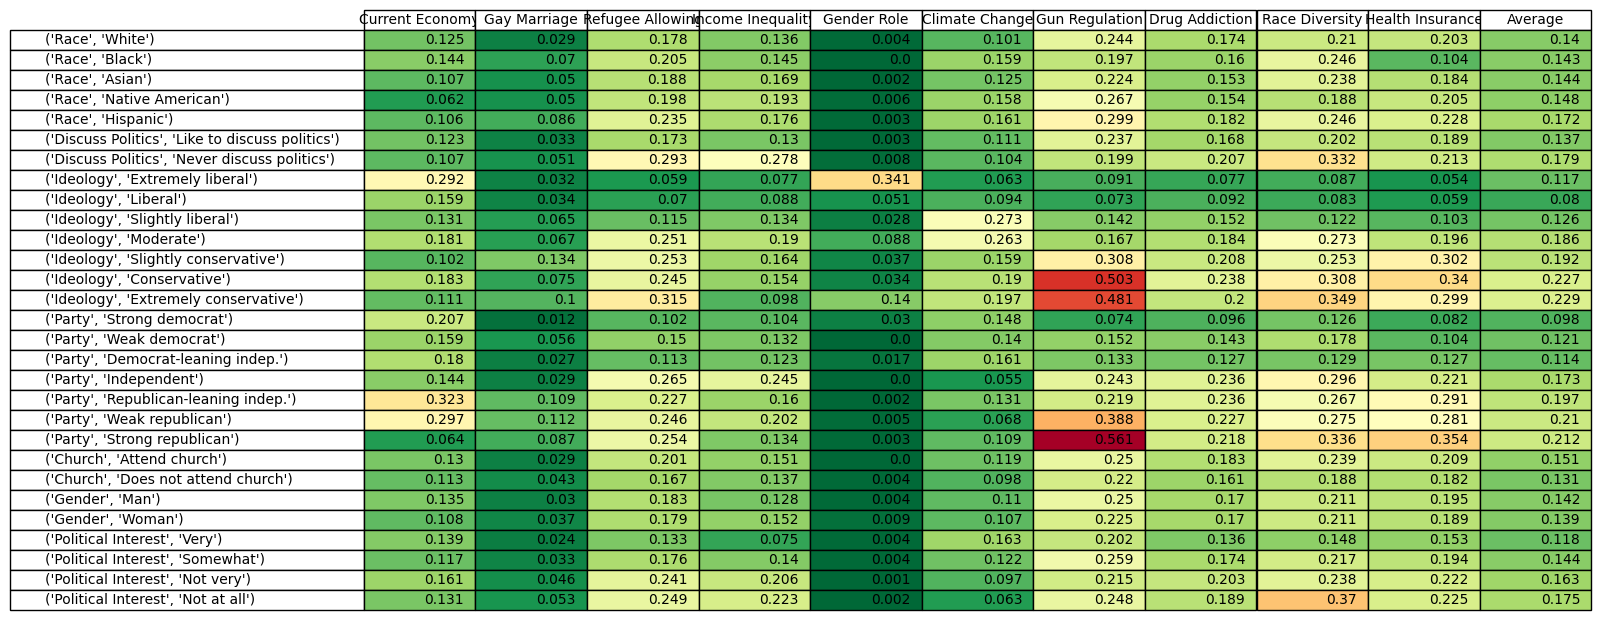

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3)) 

ax.axis("off")

table = ax.table(
    cellText=replicate_jsd_groups_df.round(3).values,
    colLabels=replicate_jsd_groups_df.columns,
    rowLabels=replicate_jsd_groups_df.index,
    loc="center"
)

cmap = plt.cm.RdYlGn_r 

vals = replicate_jsd_groups_df.values.flatten()
norm = (vals - vals.min()) / (vals.max() - vals.min())

i = 0
for r in range(replicate_jsd_groups_df.shape[0]):
    for c in range(replicate_jsd_groups_df.shape[1]):
        color = cmap(norm[i])
        table[(r+1, c)].set_facecolor(color) 
        i += 1

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
# fig.tight_layout()

# --- FIX LEFT MARGIN ---
# Adjust column widths
for (r, c), cell in table.get_celld().items():
    if c == -1:  
        cell.set_width(0.18)     # row-label column
    else:
        cell.set_width(0.1)

# Tight layout fix
plt.subplots_adjust(left=0.05, right=0.98)
plt.show()



In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stratified_jsd(jsd_groups_df, title='', output_path=''):
    df = jsd_groups_df.copy()

    # Extract the Average column
    avg_col = df["Average"]

    # Sort the remaining columns by their column mean
    sorted_cols = (
        df.drop(columns=["Average"])
        .mean(axis=0)
        .sort_values()
        .index
    )

    # Rebuild the DataFrame: sorted topics + Average at the end
    df_sorted = df[ list(sorted_cols) + ["Average"] ]
   
    data = df_sorted.values
    row_labels = df_sorted.index
    col_labels = df_sorted.columns

    fig, ax = plt.subplots(figsize=(8, 5))  # adjust width/height for paper column
    # Draw heatmap
    im = ax.imshow(data, aspect='auto', cmap=plt.cm.RdYlGn_r, vmin=data.min(), vmax=data.max())

    ax.set_title(title)
    # Show all ticks and label them
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=35, ha='right', fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)
    

    # Turn spines off and create white grid lines
    for edge, spine in ax.spines.items():
        spine.set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-0.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate the cells with values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            text = f"{data[i, j]:.3f}"
            ax.text(j, i, text, ha="center", va="center", color="black", fontsize=8)

    # Colorbar (optional)
    # cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    # cbar.ax.tick_params(labelsize=9)
    # Tight layout and control margins explicitly (left controls space for row labels)
    plt.subplots_adjust(left=0.18, right=0.98, top=0.95, bottom=0.20)
    # if output_path != '':
    #     fig.savefig(output_path,
    #                 format='pdf',
    #                 bbox_inches='tight',
    #                 pad_inches=0.05,
    #                 dpi=300)
        
    plt.show()


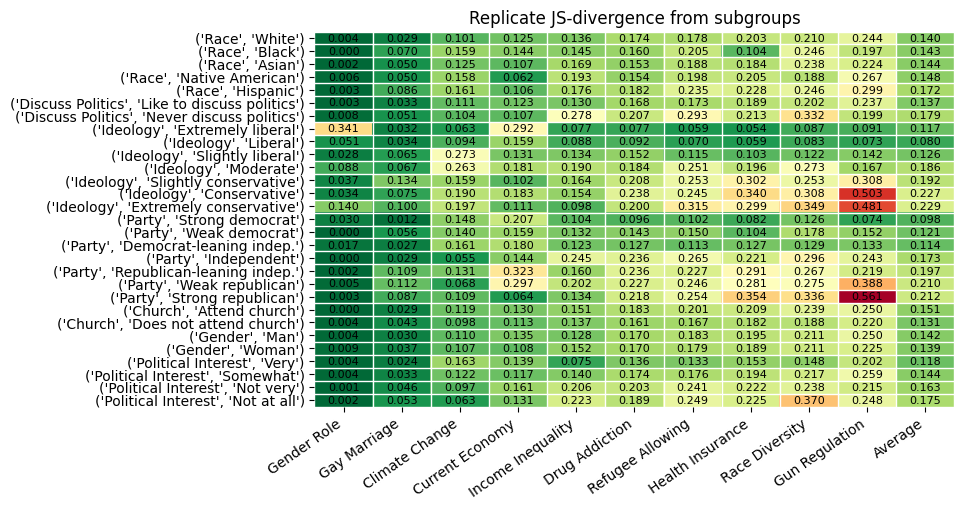

In [123]:
plot_stratified_jsd(replicate_jsd_groups_df, 'Replicate JS-divergence from subgroups','')



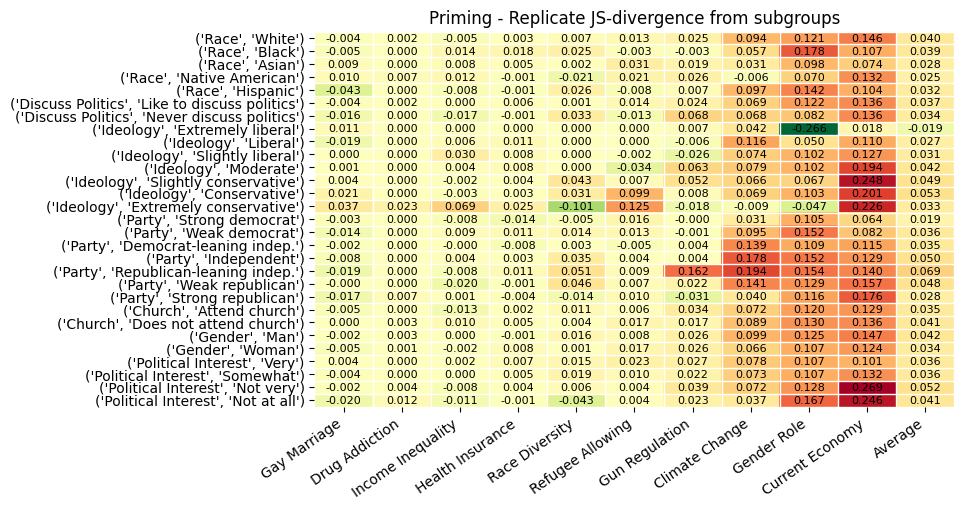

In [126]:
plot_stratified_jsd(priming_vs_replicate_jsd_df_sorted, 'Priming - Replicate JS-divergence from subgroups','')

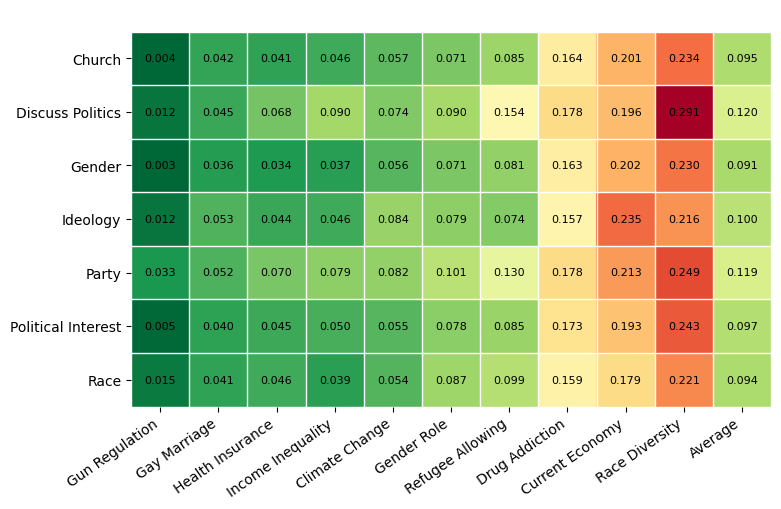

In [30]:
plot_stratified_jsd(group_averages, ' ','')